In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
#Load dataset
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print(df.head())

In [4]:
#Process the data
X = df.drop('target', axis=1)
y = df['target']

# Standardize data (VERY IMPORTANT for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#Implement the PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert to dataframe
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.44272026 0.18971182]


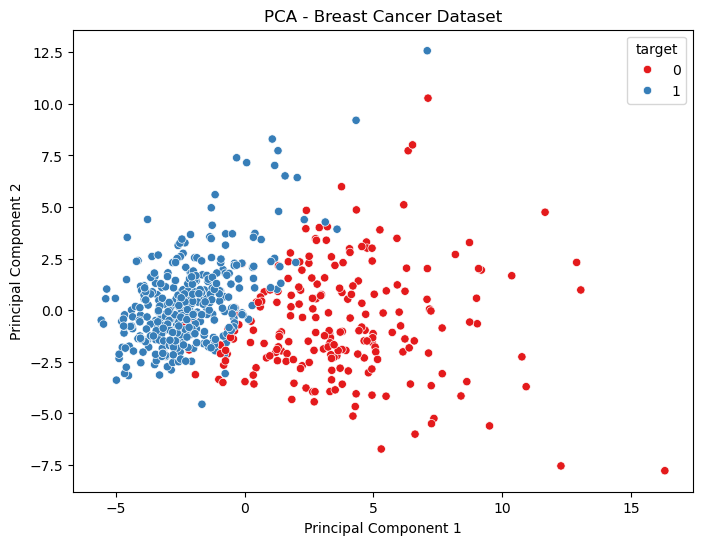

In [6]:
#Visualization 
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='target',
    data=pca_df,
    palette='Set1'
)

plt.title("PCA - Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [7]:
#Logistic regression
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [8]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 60   3]
 [  2 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [9]:
print(pca.explained_variance_ratio_)


[0.44272026 0.18971182]
